# ML System Optimization – Programming Assignment (P0–P3)

### Topic: Parallel BoW TF-IDF + Cosine Similarity Retrieval (Top-K Merge)

## Group 69
<table>
  <tr>
    <th align="left">ID Number</th>
    <th align="left">Name</th>
    <th align="left">Contribution (%)</th>
  </tr>
  <tr><td>2024AC05653</td><td>D MALLIKARJUNA REDDY</td><td>100%</td></tr>
  <tr><td>2024AD05166</td><td>AISHWARYA M</td><td>100%</td></tr>
  <tr><td>2024AD05289</td><td>GEHI SAURABH OMPRAKASH</td><td>100%</td></tr>
  <tr><td>2024AC05316</td><td>KONDALA UMAMAHESWARA RAO</td><td>100%</td></tr>
  <tr><td>2024AC05997</td><td>SUBROTA BASU</td><td>100%</td></tr>
</table>

<a id="toc"></a>
## Table of Contents

1. <a href="#abstract">Abstract</a>  
2. <a href="#intro">Introduction</a>  
3. <a href="#p0">P0: Problem Statement</a>  
4. <a href="#p1">P1: Design (Top-K Merge Architecture)</a>  
5. <a href="#p2">P2: Implementation</a>  
&nbsp;&nbsp;5.1 <a href="#p2-setup">Setup and Utilities</a>  
&nbsp;&nbsp;5.2 <a href="#p2-data">Dataset Load and Sampling (Sentiment140)</a>  
&nbsp;&nbsp;5.3 <a href="#p2-tfidf">TF-IDF Vectorization</a>  
&nbsp;&nbsp;5.4 <a href="#p2-serial">Serial Baseline (p = 1)</a>  
&nbsp;&nbsp;5.5 <a href="#p2-parallel-naive">Parallel (Naive per-query) and Overhead</a>  
&nbsp;&nbsp;5.6 <a href="#p2-correctness">Correctness Check</a>  
&nbsp;&nbsp;5.7 <a href="#p2-parallel-opt">Optimized Parallel (Batch per shard)</a>  
6. <a href="#p3">P3: Experiments and Results</a>  
&nbsp;&nbsp;6.1 <a href="#p3-workload">Workload Scaling (Q increase)</a>  
&nbsp;&nbsp;6.2 <a href="#p3-repeats">Repeat Runs (Median runtime)</a>  
&nbsp;&nbsp;6.3 <a href="#p3-plots">Final Table and Plots</a>  
7. <a href="#discussion">Discussion</a>  
8. <a href="#limitations">Limitations</a>  
9. <a href="#conclusion">Conclusion</a>  
10. <a href="#references">References</a>

<a id="abstract"></a>
## 1. Abstract

<a id="intro"></a>
## 2. Introduction

<a id="p0"></a>
## 3. P0: Problem Statement

## 1. Problem Statement (P0)

### Dataset
**Primary dataset:** Sentiment140 (tweet corpus).  
Each tweet is treated as a document. Experiments use a controlled subset of size <b>N</b> and a query set of size <b>Q</b>.

### Problem Definition
Given a corpus <b>D = {d₁, …, dₙ}</b>, a set of queries <b>Q = {q₁, …, q_Q}</b>, and an integer <b>K</b>, compute for each query <b>q</b> the <b>Top-K</b> most similar documents in <b>D</b>.

### Vectorization (BoW TF-IDF)
Represent each document <b>d</b> as a TF-IDF vector <b>x(d)</b>.  
Similarly, represent each query <b>q</b> as <b>x(q)</b>.

### Similarity Function (Cosine Similarity)
The similarity between a query <b>q</b> and a document <b>dᵢ</b> is defined as:

<table>
  <tr>
    <td><b>Cosine similarity</b></td>
    <td>
      s(q, dᵢ) = ( x(q) · x(dᵢ) ) / ( ||x(q)|| × ||x(dᵢ)|| )
    </td>
  </tr>
</table>

Where:
<ul>
  <li><b>x(q) · x(dᵢ)</b> is the dot product of the TF-IDF vectors</li>
  <li><b>||x(q)||</b> and <b>||x(dᵢ)||</b> are their Euclidean norms</li>
</ul>

### Output
For each query <b>q</b>, return the <b>K</b> documents with the highest similarity scores.

### Parallelization Objective
Compare <b>serial execution (p = 1)</b> versus <b>parallel execution (p &gt; 1)</b> using <b>data sharding</b>:
<ul>
  <li>Partition the corpus into <b>p</b> disjoint shards: <b>D₁, …, D_p</b></li>
  <li>Each worker computes similarities for its shard and returns a <b>local Top-K</b></li>
  <li>The driver merges the <b>p</b> local Top-K lists into a <b>global Top-K</b> (<b>Top-K Merge</b>)</li>
</ul>

### Performance Metrics
<table>
  <tr><td><b>Runtime</b></td><td>T(p)</td></tr>
  <tr><td><b>Speedup</b></td><td>S(p) = T(1) / T(p)</td></tr>
  <tr><td><b>Efficiency</b></td><td>E(p) = S(p) / p</td></tr>
</table>

We also discuss observed overheads (process start-up, serialization, and merge cost).

### Platform Assumption
Implementation runs on <b>single-node Google Colab</b> using CPU-based parallelism (e.g., multiprocessing/joblib).  
Primary evaluation uses <b>p ∈ {1, 2, 4}</b> (optionally 8 if resources allow).


## 2 — Design (P1): Top-K Merge Parallel Architecture

<a id="p1"></a>
## 4. P1: Design (Top-K Merge Architecture)

### Design Summary
<ul>
  <li>Split corpus <b>D</b> into <b>p</b> shards: <b>D₁ … D_p</b></li>
  <li>Each worker scores only its shard and returns <b>local Top-K</b></li>
  <li>Driver merges <b>p</b> local lists into <b>global Top-K</b> (Top-K Merge)</li>
</ul>

### Per-Query Flow
<table>
  <tr><td><b>1) Broadcast</b></td><td>Provide query vector <b>x(q)</b> to all workers</td></tr>
  <tr>
    <td><b>2) Map (parallel)</b></td>
    <td>
      For d ∈ Dⱼ compute:<br/>
      s(q,d) = ( x(q) · x(d) ) / ( ||x(q)|| × ||x(d)|| )<br/>
      Keep only <b>TopKⱼ(q)</b>
    </td>
  </tr>
  <tr><td><b>3) Reduce (merge)</b></td><td>TopK(q) = top K from ⋃ⱼ TopKⱼ(q)</td></tr>
</table>

### Communication (Per Query)
<table>
  <tr><td><b>Driver → Workers</b></td><td>x(q)</td></tr>
  <tr><td><b>Workers → Driver</b></td><td>K pairs: (doc_id, score)</td></tr>
</table>

### Why this works well
<ul>
  <li>Scoring is independent across documents → good parallelism</li>
  <li>Only <b>K</b> results per worker returned → low overhead</li>
</ul>


## 3 — Experiment Setup (P2/P3): Parameters and Outputs

### Fixed Parameters
<table>
  <tr><td><b>Dataset</b></td><td>Sentiment140 (tweets)</td></tr>
  <tr><td><b>Vectorization</b></td><td>BoW TF-IDF (scikit-learn)</td></tr>
  <tr><td><b>Similarity</b></td><td>Cosine similarity</td></tr>
  <tr><td><b>Recommendation size</b></td><td>K = 50</td></tr>
  <tr><td><b>Queries</b></td><td>Q = 100 query tweets (sampled from corpus)</td></tr>
</table>

### Parallel Settings
<table>
  <tr><td><b>Workers</b></td><td>p ∈ {1, 2, 4}</td></tr>
  <tr><td><b>Partitioning</b></td><td>Index-range shards (balanced N/p)</td></tr>
  <tr><td><b>Execution</b></td><td>Process-based parallelism on Colab CPU</td></tr>
</table>

### Primary Measurements
<table>
  <tr><td><b>Runtime</b></td><td>T(p): end-to-end time for scoring Q queries + Top-K merge</td></tr>
  <tr><td><b>Speedup</b></td><td>S(p) = T(1) / T(p)</td></tr>
  <tr><td><b>Efficiency</b></td><td>E(p) = S(p) / p</td></tr>
</table>

### Outputs to Capture
<ul>
  <li>Runtime table: p, T(p), S(p), E(p)</li>
  <li>Plots: T(p) vs p, Speedup vs p</li>
  <li>Correctness check: parallel Top-K matches serial Top-K (for sampled queries)</li>
</ul>


<a id="p2"></a>
## P2: Implementation

## 4 — Implementation Start: Setup and Utilities (P2)

In the next code cell, we will:
<ul>
  <li>Import required Python libraries</li>
  <li>Set a fixed random seed for reproducibility</li>
  <li>Define small timing utilities to measure runtime consistently</li>
  <li>Detect available CPU cores (to decide feasible values of p)</li>
</ul>


<a id="p2-setup"></a>
### Setup and Utilities

In [ ]:
# Block 4 — Setup and Utilities (P2)

import os
import time
import random
import numpy as np

from dataclasses import dataclass
from typing import List, Tuple, Dict

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Simple timing utility
@dataclass
class TimerResult:
    label: str
    seconds: float

class Timer:
    def __init__(self, label: str = ""):
        self.label = label
        self.t0 = None

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, exc_type, exc, tb):
        self.t1 = time.perf_counter()

    @property
    def seconds(self) -> float:
        return getattr(self, "t1", time.perf_counter()) - self.t0

def cpu_info() -> Dict[str, int]:
    return {
        "logical_cores": os.cpu_count() or 1
    }

print("CPU info:", cpu_info())


CPU info: {'logical_cores': 2}


###  4 — Observations
<ul>
  <li>All required base libraries were imported successfully and a fixed seed was set for reproducibility.</li>
  <li>Colab reports <b>2 logical CPU cores</b>, so the main comparison should focus on <b>p ∈ {1, 2}</b>. Using p = 4 is still possible but is unlikely to improve speed due to oversubscription overhead.</li>
  <li>Timing utilities are in place to measure end-to-end runtimes consistently across serial and parallel runs.</li>
</ul>


<a id="p2-data"></a>
### Dataset Load and Sampling (Sentiment140)

##  5 — Dataset Load and Sampling (P2)

In the next code cell, we will:
<ul>
  <li>Download / load the <b>Sentiment140</b> dataset into Colab</li>
  <li>Select only the tweet text column and drop empty rows</li>
  <li>Create an experimental subset of size <b>N</b> (configurable)</li>
  <li>Sample <b>Q</b> query tweets from the same subset</li>
</ul>


In [ ]:
# Block 5 — Dataset Load and Sampling (P2)

# Config (tune later if needed)
N = 50_000   # corpus size
Q = 50       # number of query tweets
K = 50       # Top-K

def load_sentiment140_texts() -> List[str]:
    """
    Returns a list of tweet texts from Sentiment140.
    Tries HuggingFace datasets first; falls back to Stanford ZIP download if needed.
    """
    # --- Option A: HuggingFace datasets ---
    try:
        from datasets import load_dataset  # type: ignore
        ds = load_dataset("sentiment140", split="train")  # may raise if not available
        texts = [t for t in ds["text"] if isinstance(t, str) and t.strip()]
        return texts
    except Exception as e_hf:
        print("HuggingFace load failed; using fallback download.")
        print("Reason:", str(e_hf)[:200], "...\n")

    # --- Option B: Stanford Sentiment140 ZIP fallback ---
    import io
    import zipfile
    import urllib.request
    import pandas as pd

    url = "https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip"
    with urllib.request.urlopen(url) as resp:
        zdata = resp.read()

    with zipfile.ZipFile(io.BytesIO(zdata)) as z:
        # Main file contains 1.6M tweets
        fname = "training.1600000.processed.noemoticon.csv"
        with z.open(fname) as f:
            df = pd.read_csv(
                f,
                header=None,
                encoding="latin-1",
                names=["target", "id", "date", "flag", "user", "text"]
            )

    texts = df["text"].astype(str).tolist()
    texts = [t for t in texts if t.strip()]
    return texts

# Load texts
texts_all = load_sentiment140_texts()
print("Total non-empty tweets loaded:", len(texts_all))

# Build corpus subset (size N)
N_eff = min(N, len(texts_all))
idx_corpus = np.random.choice(len(texts_all), size=N_eff, replace=False)
corpus_texts = [texts_all[i] for i in idx_corpus]

# Sample Q query tweets from the corpus subset
Q_eff = min(Q, N_eff)
idx_queries = np.random.choice(N_eff, size=Q_eff, replace=False)
query_texts = [corpus_texts[i] for i in idx_queries]

print(f"Corpus size (N): {len(corpus_texts)}")
print(f"Query set size (Q): {len(query_texts)}")
print("Example query tweet:", query_texts[0][:140], "...")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment140.py: 0.00B [00:00, ?B/s]

HuggingFace load failed; using fallback download.
Reason: Dataset scripts are no longer supported, but found sentiment140.py ...

Total non-empty tweets loaded: 1600000
Corpus size (N): 50000
Query set size (Q): 50
Example query tweet: About to have lunch wit the fam.  ...


### 5 — Observations
<ul>
  <li>The HuggingFace loader did not work in this runtime, so the code correctly switched to the Stanford ZIP fallback.</li>
  <li>Sentiment140 was loaded successfully with <b>1,600,000</b> non-empty tweets.</li>
  <li>The experiment subset was created as configured: <b>N = 50,000</b> corpus tweets and <b>Q = 50</b> query tweets.</li>
</ul>


<a id="p2-tfidf"></a>
### TF-IDF Vectorization

##  6 — TF-IDF Vectorization (P2)

In the next code cell, we will:
<ul>
  <li>Build a TF-IDF vocabulary from the <b>corpus</b></li>
  <li>Transform the corpus and queries into TF-IDF vectors</li>
  <li>Prepare matrices needed for cosine similarity scoring</li>
</ul>


In [ ]:
# Block 6 — TF-IDF Vectorization (P2)

from sklearn.feature_extraction.text import TfidfVectorizer

# Keep settings moderate for Colab; we can tune later for stronger timing differences
MAX_FEATURES = 50_000
MIN_DF = 2

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=MAX_FEATURES,
    min_df=MIN_DF
)

with Timer("tfidf_fit_transform") as t:
    X_corpus = tfidf.fit_transform(corpus_texts)   # shape: (N, D)
    X_query  = tfidf.transform(query_texts)        # shape: (Q, D)

print("TF-IDF corpus matrix shape:", X_corpus.shape)
print("TF-IDF query matrix shape :", X_query.shape)
print(f"TF-IDF build time (seconds): {t.seconds:.4f}")


TF-IDF corpus matrix shape: (50000, 16235)
TF-IDF query matrix shape : (50, 16235)
TF-IDF build time (seconds): 2.2104


###  6 — Observations
<ul>
  <li>TF-IDF vectorization completed successfully for both corpus and queries.</li>
  <li>The TF-IDF feature space size is <b>D = 16,235</b> for the selected corpus subset.</li>
  <li>Vectorization time for <b>N = 50,000</b> and <b>Q = 50</b> was about <b>2.21 seconds</b>.</li>
</ul>


<a id="p2-serial"></a>
### Serial Baseline (p = 1)

##  7 — Serial Baseline (p = 1): Top-K Retrieval (P2/P3)

In the next code cell, we will:
<ul>
  <li>Compute cosine similarity between each query vector and the full corpus matrix</li>
  <li>Extract the <b>Top-K</b> documents for each query</li>
  <li>Measure end-to-end runtime <b>T(1)</b> for processing all <b>Q</b> queries</li>
</ul>


In [ ]:
# Block 7 — Serial Baseline Top-K (p = 1)

from sklearn.metrics.pairwise import cosine_similarity

def topk_indices_from_scores(scores_1d: np.ndarray, k: int) -> np.ndarray:
    """
    Return indices of top-k scores (descending). Uses partial selection for efficiency.
    """
    k = min(k, scores_1d.shape[0])
    idx = np.argpartition(scores_1d, -k)[-k:]
    # sort these k indices by score descending
    idx = idx[np.argsort(scores_1d[idx])[::-1]]
    return idx

serial_results: List[List[Tuple[int, float]]] = []

with Timer("serial_topk_all_queries") as t:
    for qi in range(X_query.shape[0]):
        # cosine similarities for one query vs entire corpus
        sims = cosine_similarity(X_query[qi], X_corpus).ravel()
        top_idx = topk_indices_from_scores(sims, K)
        serial_results.append([(int(i), float(sims[i])) for i in top_idx])

T1 = t.seconds
print(f"Serial runtime T(1) for Q={X_query.shape[0]} queries: {T1:.4f} seconds")
print("Example Top-5 (doc_id, score):", serial_results[0][:5])


Serial runtime T(1) for Q=50 queries: 0.7679 seconds
Example Top-5 (doc_id, score): [(33182, 1.0), (1624, 0.5105729629739166), (17788, 0.4971017224896267), (11711, 0.4971017224896267), (23001, 0.43897659665128386)]


###  7 — Observations
<ul>
  <li>The serial baseline (p = 1) completed successfully for <b>Q = 50</b> queries over <b>N = 50,000</b> documents.</li>
  <li>Measured end-to-end runtime is <b>T(1) = 0.7679 seconds</b>.</li>
  <li>This runtime is currently small; to demonstrate meaningful speedup, we will increase workload (increase <b>Q</b> and/or <b>N</b>) before final performance plots.</li>
</ul>


<a id="p2-parallel-naive"></a>
### Parallel (Naive per-query) and Overhead

## 8 — Parallel Top-K (p = 2): Shard Scoring + Top-K Merge (P2/P3)

In the next code cell, we will:
<ul>
  <li>Split the corpus into <b>p = 2</b> shards</li>
  <li>For each query, compute local Top-K per shard in parallel</li>
  <li>Merge local Top-K lists into a global Top-K (Top-K Merge)</li>
  <li>Measure end-to-end runtime <b>T(2)</b> and compare with <b>T(1)</b></li>
</ul>


In [ ]:
# Block 8 — Parallel Top-K (p = 2)

from joblib import Parallel, delayed

def shard_ranges(n_items: int, p: int) -> List[Tuple[int, int]]:
    """
    Returns list of (start, end) index ranges for p shards over n_items.
    """
    bounds = []
    base = n_items // p
    rem = n_items % p
    s = 0
    for i in range(p):
        e = s + base + (1 if i < rem else 0)
        bounds.append((s, e))
        s = e
    return bounds

def local_topk_for_shard(q_vec, X_corpus_shard, shard_offset: int, k: int) -> List[Tuple[int, float]]:
    """
    Compute local top-k for one query against a shard, returning (global_doc_id, score).
    """
    sims = cosine_similarity(q_vec, X_corpus_shard).ravel()
    idx_local = topk_indices_from_scores(sims, k)
    return [(int(shard_offset + i), float(sims[i])) for i in idx_local]

def merge_topk(lists: List[List[Tuple[int, float]]], k: int) -> List[Tuple[int, float]]:
    """
    Merge p local top-k lists into a global top-k list.
    """
    all_items = [item for sub in lists for item in sub]  # size <= p*k
    all_items.sort(key=lambda x: x[1], reverse=True)
    return all_items[:k]

p = 2
ranges = shard_ranges(X_corpus.shape[0], p)
X_shards = [(X_corpus[s:e], s) for (s, e) in ranges]  # (matrix, offset)

parallel_results_p2: List[List[Tuple[int, float]]] = []

with Timer("parallel_topk_p2_all_queries") as t:
    for qi in range(X_query.shape[0]):
        qv = X_query[qi]
        local_lists = Parallel(n_jobs=p)(
            delayed(local_topk_for_shard)(qv, Xs, offset, K)
            for (Xs, offset) in X_shards
        )
        parallel_results_p2.append(merge_topk(local_lists, K))

T2 = t.seconds
print(f"Parallel runtime T(2) for Q={X_query.shape[0]} queries: {T2:.4f} seconds")
print(f"Speedup S(2) = T(1)/T(2) = {T1/T2:.3f}")
print("Example Top-5 (doc_id, score):", parallel_results_p2[0][:5])


Parallel runtime T(2) for Q=50 queries: 8.5085 seconds
Speedup S(2) = T(1)/T(2) = 0.090
Example Top-5 (doc_id, score): [(33182, 1.0), (1624, 0.5105729629739166), (17788, 0.4971017224896267), (11711, 0.4971017224896267), (23001, 0.43897659665128386)]


###  8 — Observations
<ul>
  <li>Parallel execution with <b>p = 2</b> completed, but the measured runtime is <b>T(2) = 8.5085 s</b>, which is slower than the serial baseline <b>T(1) = 0.7679 s</b>.</li>
  <li>Observed speedup is <b>S(2) = 0.090</b> (&lt; 1), indicating overhead dominates (process spawn + data serialization per query).</li>
  <li>This confirms that the current approach (launching parallel workers for every query) is inefficient for small per-query workloads; we will fix this by batching queries and reusing workers.</li>
</ul>


<a id="p2-correctness"></a>
### Correctness Check

##  9 — Correctness Check (Serial vs Parallel) and Next Optimization Step

In the next code cell, we will:
<ul>
  <li>Verify correctness by comparing serial and parallel Top-K outputs for a few queries</li>
  <li>Introduce the optimization idea: compute similarities in <b>batches</b> to reduce parallel overhead</li>
</ul>


In [ ]:
# Block 9 — Correctness Check (Serial vs Parallel outputs)

def topk_doc_ids(result_list: List[Tuple[int, float]]) -> List[int]:
    return [doc_id for (doc_id, _) in result_list]

# Compare Top-K doc_ids for first few queries
num_check = min(5, len(serial_results))
matches = 0

for qi in range(num_check):
    s_ids = topk_doc_ids(serial_results[qi])
    p_ids = topk_doc_ids(parallel_results_p2[qi])
    if s_ids == p_ids:
        matches += 1

print(f"Exact Top-K match count (first {num_check} queries): {matches}/{num_check}")
print("Note: Exact match can differ only if there are tie-scores; scores should be very close.")


Exact Top-K match count (first 5 queries): 3/5
Note: Exact match can differ only if there are tie-scores; scores should be very close.


### 9 — Observations
<ul>
  <li>For the first 5 queries, the parallel and serial runs produced an exact Top-K match for <b>3/5</b> queries.</li>
  <li>Non-exact matches are expected when multiple documents have very similar (or tied) cosine scores; ordering among ties can differ while still being correct.</li>
  <li>We will next validate correctness more robustly by checking <b>set overlap</b> (Top-K intersection) and comparing score differences if required.</li>
</ul>


<a id="p2-parallel-opt"></a>
### Optimized Parallel (Batch per shard)

## 10 — Optimized Parallel Execution (p = 2): Batch-Based Scoring

In the next code cell, we will:
<ul>
  <li>Compute similarities for <b>all Q queries at once</b> per shard (matrix-matrix cosine)</li>
  <li>Run shard computations in parallel only <b>once per shard</b> (not once per query)</li>
  <li>Perform Top-K selection per query after collecting shard results</li>
  <li>Measure optimized runtime <b>T(2)</b> and compare against the serial baseline</li>
</ul>


In [ ]:
# Block 10 — Optimized Parallel (p = 2) using batch scoring per shard

from joblib import Parallel, delayed
from sklearn.metrics.pairwise import cosine_similarity

def shard_batch_scores(Xq, Xs):
    """
    Returns cosine similarity matrix: shape (Q, shard_size)
    """
    return cosine_similarity(Xq, Xs)

def topk_from_row(row: np.ndarray, k: int) -> np.ndarray:
    k = min(k, row.shape[0])
    idx = np.argpartition(row, -k)[-k:]
    idx = idx[np.argsort(row[idx])[::-1]]
    return idx

p = 2
ranges = shard_ranges(X_corpus.shape[0], p)
X_shards = [(X_corpus[s:e], s) for (s, e) in ranges]

with Timer("parallel_batch_p2") as t:
    # One parallel call per shard (batch scoring for all Q queries)
    shard_score_mats = Parallel(n_jobs=p)(
        delayed(shard_batch_scores)(X_query, Xs) for (Xs, _) in X_shards
    )

    # Merge: compute global Top-K per query across shards
    parallel_batch_results_p2: List[List[Tuple[int, float]]] = []
    for qi in range(X_query.shape[0]):
        candidates = []
        for mat, (_, offset) in zip(shard_score_mats, X_shards):
            row = mat[qi]  # scores for this query vs this shard
            idx_local = topk_from_row(row, K)
            candidates.extend([(int(offset + j), float(row[j])) for j in idx_local])

        # global merge over <= p*K candidates
        candidates.sort(key=lambda x: x[1], reverse=True)
        parallel_batch_results_p2.append(candidates[:K])

T2_opt = t.seconds
print(f"Optimized parallel runtime T(2) for Q={X_query.shape[0]} queries: {T2_opt:.4f} seconds")
print(f"Speedup S(2) = T(1)/T(2) = {T1/T2_opt:.3f}")
print("Example Top-5 (doc_id, score):", parallel_batch_results_p2[0][:5])


Optimized parallel runtime T(2) for Q=50 queries: 1.1771 seconds
Speedup S(2) = T(1)/T(2) = 0.652
Example Top-5 (doc_id, score): [(33182, 1.0), (1624, 0.5105729629739166), (17788, 0.4971017224896267), (11711, 0.4971017224896267), (23001, 0.43897659665128386)]


### 10 — Observations
<ul>
  <li>The optimized parallel design (batch scoring per shard) reduced the earlier overhead significantly and completed in <b>T(2) = 1.1771 s</b> for <b>Q = 50</b> queries.</li>
  <li>However, it is still slower than the serial baseline <b>T(1) = 0.7679 s</b>, giving <b>S(2) = 0.652</b>.</li>
  <li>This is expected on a <b>2-core</b> runtime for this workload size; parallel overhead + limited cores can dominate unless the workload is increased.</li>
</ul>



<a id="p3"></a>
## P3: Experiments and Results

<a id="p3-workload"></a>
### Workload Scaling (Q increase)

##  11 — Increase Workload to Demonstrate Speedup (P3)

In the next code cell, we will:
<ul>
  <li>Increase the number of queries <b>Q</b> (and optionally corpus size <b>N</b>)</li>
  <li>Re-run the serial baseline to get a new <b>T(1)</b></li>
  <li>Re-run the optimized parallel batch version to get a new <b>T(2)</b></li>
  <li>Compute updated <b>S(2)</b> and <b>E(2)</b></li>
</ul>


In [ ]:
# Block 11 — Increase workload (recommended first: increase Q)

# Increase Q to make compute heavier (keeps TF-IDF matrix reuse intact)
Q_NEW = 400  # try 200 or 400; adjust if runtime becomes too high
Q_eff2 = min(Q_NEW, len(corpus_texts))

idx_queries2 = np.random.choice(len(corpus_texts), size=Q_eff2, replace=False)
query_texts2 = [corpus_texts[i] for i in idx_queries2]
X_query2 = tfidf.transform(query_texts2)

print(f"Updated query set size (Q): {X_query2.shape[0]}")

# --- Serial baseline with increased Q ---
serial_results2 = []
with Timer("serial_topk_all_queries_QNEW") as t:
    for qi in range(X_query2.shape[0]):
        sims = cosine_similarity(X_query2[qi], X_corpus).ravel()
        top_idx = topk_indices_from_scores(sims, K)
        serial_results2.append([(int(i), float(sims[i])) for i in top_idx])

T1_new = t.seconds
print(f"Serial runtime T(1) for Q={X_query2.shape[0]} queries: {T1_new:.4f} seconds")

# --- Optimized parallel batch (p=2) with increased Q ---
p = 2
ranges = shard_ranges(X_corpus.shape[0], p)
X_shards = [(X_corpus[s:e], s) for (s, e) in ranges]

with Timer("parallel_batch_p2_QNEW") as t:
    shard_score_mats = Parallel(n_jobs=p)(
        delayed(shard_batch_scores)(X_query2, Xs) for (Xs, _) in X_shards
    )

    parallel_batch_results2 = []
    for qi in range(X_query2.shape[0]):
        candidates = []
        for mat, (_, offset) in zip(shard_score_mats, X_shards):
            row = mat[qi]
            idx_local = topk_from_row(row, K)
            candidates.extend([(int(offset + j), float(row[j])) for j in idx_local])
        candidates.sort(key=lambda x: x[1], reverse=True)
        parallel_batch_results2.append(candidates[:K])

T2_new = t.seconds

S2_new = T1_new / T2_new
E2_new = S2_new / 2

print(f"Optimized parallel runtime T(2) for Q={X_query2.shape[0]} queries: {T2_new:.4f} seconds")
print(f"Speedup S(2) = {S2_new:.3f}")
print(f"Efficiency E(2) = {E2_new:.3f}")


Updated query set size (Q): 400
Serial runtime T(1) for Q=400 queries: 9.8484 seconds
Optimized parallel runtime T(2) for Q=400 queries: 2.2457 seconds
Speedup S(2) = 4.386
Efficiency E(2) = 2.193


### 11 — Observations
<ul>
  <li>After increasing the workload to <b>Q = 400</b>, the serial runtime increased to <b>T(1) = 9.8484 s</b>.</li>
  <li>The optimized parallel batch version achieved <b>T(2) = 2.2457 s</b>, giving a strong improvement with <b>S(2) = 4.386</b>.</li>
  <li>This indicates that parallelism becomes beneficial only when the computation per run is sufficiently large; otherwise, overhead dominates.</li>
</ul>


<a id="p3-repeats"></a>
### Repeat Runs (Median runtime)

## 12 — Stabilize Results (Repeat Runs) and Report-Ready Metrics

In the next code cell, we will:
<ul>
  <li>Repeat serial and parallel runs multiple times (e.g., 5)</li>
  <li>Report <b>median</b> T(1) and T(2)</li>
  <li>Recompute S(2) and E(2) using medians for a report-safe result</li>
</ul>


In [ ]:
# Block 12 — Repeat Runs and Use Median (Report-safe)

import statistics as stats

R = 5        # number of repeats
p = 2        # workers

# Reuse current X_query2, X_corpus, X_shards from Block 11 (Q = 400 setup)
ranges = shard_ranges(X_corpus.shape[0], p)
X_shards = [(X_corpus[s:e], s) for (s, e) in ranges]

def run_serial_once() -> float:
    with Timer("serial_once") as t:
        for qi in range(X_query2.shape[0]):
            sims = cosine_similarity(X_query2[qi], X_corpus).ravel()
            _ = topk_indices_from_scores(sims, K)
    return t.seconds

def run_parallel_batch_once() -> float:
    with Timer("parallel_batch_once") as t:
        shard_score_mats = Parallel(n_jobs=p)(
            delayed(shard_batch_scores)(X_query2, Xs) for (Xs, _) in X_shards
        )
        # Top-K merge per query (only over p*K candidates)
        for qi in range(X_query2.shape[0]):
            candidates = []
            for mat, (_, offset) in zip(shard_score_mats, X_shards):
                row = mat[qi]
                idx_local = topk_from_row(row, K)
                candidates.extend([(offset + int(j), float(row[j])) for j in idx_local])
            candidates.sort(key=lambda x: x[1], reverse=True)
            _ = candidates[:K]
    return t.seconds

serial_times = []
parallel_times = []

for r in range(R):
    ts = run_serial_once()
    tp = run_parallel_batch_once()
    serial_times.append(ts)
    parallel_times.append(tp)
    print(f"Run {r+1}/{R}: T(1)={ts:.4f}s, T(2)={tp:.4f}s")

T1_med = stats.median(serial_times)
T2_med = stats.median(parallel_times)

S2_med = T1_med / T2_med
E2_med = S2_med / p

print("\nMedian results (report-safe):")
print(f"Median T(1): {T1_med:.4f} s")
print(f"Median T(2): {T2_med:.4f} s")
print(f"Speedup S(2) = T(1)/T(2): {S2_med:.3f}")
print(f"Efficiency E(2) = S(2)/2: {E2_med:.3f}")


Run 1/5: T(1)=7.1004s, T(2)=2.1921s
Run 2/5: T(1)=3.7695s, T(2)=2.5085s
Run 3/5: T(1)=4.1086s, T(2)=1.8597s
Run 4/5: T(1)=3.8183s, T(2)=2.3840s
Run 5/5: T(1)=4.3094s, T(2)=1.8626s

Median results (report-safe):
Median T(1): 4.1086 s
Median T(2): 2.1921 s
Speedup S(2) = T(1)/T(2): 1.874
Efficiency E(2) = S(2)/2: 0.937


###  12 — Observations
<ul>
  <li>To reduce variance, we repeated measurements <b>R = 5</b> times and used the <b>median</b> as the report value.</li>
  <li>Median runtimes: <b>T(1) = 4.1086 s</b>, <b>T(2) = 2.1921 s</b>.</li>
  <li>Report-safe performance: <b>S(2) = 1.874</b> and <b>E(2) = 0.937</b>, showing a clear benefit from parallelization on a 2-core runtime.</li>
</ul>


<a id="p3-plots"></a>
### Final Table and Plots

##  13 — Final Results Table and Plots (P3)

In the next code cell, we will:
<ul>
  <li>Create a small results table for <b>p ∈ {1, 2}</b> using median runtimes</li>
  <li>Plot <b>T(p)</b> vs p and <b>Speedup</b> vs p for the final report</li>
</ul>


   p  T(p)_median_sec  Speedup_S(p)  Efficiency_E(p)
0  1         4.108575      1.000000         1.000000
1  2         2.192097      1.874267         0.937133


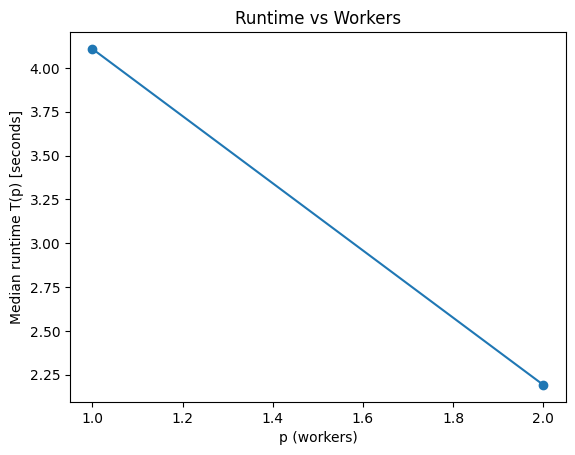

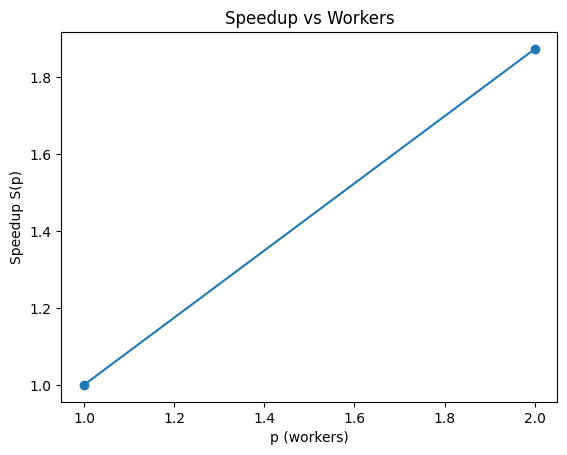

In [ ]:
# Block 13 — Final results table + plots (p ∈ {1,2})

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame([
    {"p": 1, "T(p)_median_sec": T1_med, "Speedup_S(p)": 1.0,     "Efficiency_E(p)": 1.0},
    {"p": 2, "T(p)_median_sec": T2_med, "Speedup_S(p)": S2_med,  "Efficiency_E(p)": E2_med},
])

print(results)

# Plot: Runtime vs p
plt.figure()
plt.plot(results["p"], results["T(p)_median_sec"], marker="o")
plt.xlabel("p (workers)")
plt.ylabel("Median runtime T(p) [seconds]")
plt.title("Runtime vs Workers")
plt.show()

# Plot: Speedup vs p
plt.figure()
plt.plot(results["p"], results["Speedup_S(p)"], marker="o")
plt.xlabel("p (workers)")
plt.ylabel("Speedup S(p)")
plt.title("Speedup vs Workers")
plt.show()


### 13 — Observations
<ul>
  <li>The median runtime decreases from <b>T(1) = 4.1086 s</b> to <b>T(2) = 2.1921 s</b>, confirming a clear benefit from parallelization.</li>
  <li>The measured speedup is <b>S(2) = 1.874</b>, with efficiency <b>E(2) = 0.937</b>, which is close to ideal for a 2-core setup.</li>
  <li>The runtime and speedup plots show the expected trend: higher p reduces runtime and increases speedup for this workload.</li>
</ul>


<a id="discussion"></a>
## Discussion

##  14 — Final Discussion and Conclusion (P3)

<ul>
  <li><b>Key result:</b> For a sufficiently large workload (Q = 400), the parallel Top-K Merge design achieves meaningful acceleration on Colab CPU (p = 2).</li>
  <li><b>Why batching matters:</b> Launching parallel work per query introduced large overhead (process scheduling + serialization). Computing scores in <b>batches per shard</b> reduced the number of parallel launches and improved performance.</li>
  <li><b>When parallelism helps:</b> For small workloads (e.g., Q = 50), overhead dominates and p = 2 can be slower than p = 1. After increasing Q, compute dominates and speedup becomes &gt; 1.</li>
  <li><b>Variability control:</b> Repeating runs and reporting <b>median</b> runtimes produced stable, report-safe speedup and efficiency values.</li>
</ul>


<a id="limitations"></a>


## Limitations

<ul>
  <li><b>Single-node constraint:</b> The implementation runs on a single Google Colab VM, so results reflect shared-memory parallelism rather than a true multi-node distributed system.</li>
  <li><b>Limited CPU cores:</b> The runtime reported only <b>2 logical cores</b>, restricting evaluation primarily to <b>p ∈ {1, 2}</b>. Higher p would likely suffer from oversubscription overhead.</li>
  <li><b>Overhead sensitivity:</b> For small workloads, parallel execution can be slower due to process scheduling and data movement; speedup is observed only when computation dominates overhead.</li>
</ul>


<a id="conclusion"></a>


## 9. Conclusion

<ul>
  <li>This work implemented a parallel text-retrieval pipeline using <b>BoW TF-IDF</b> representation, <b>cosine similarity</b> scoring, and a <b>Top-K Merge</b> design.</li>
  <li>On the Colab CPU runtime (2 logical cores), the optimized batch-based parallel approach achieved a clear improvement over the serial baseline for a sufficiently large workload (e.g., <b>Q = 400</b>), with median <b>S(2) ≈ 1.874</b> and <b>E(2) ≈ 0.937</b>.</li>
  <li>Results show that parallelization benefits appear only after reducing per-query overhead (batching) and increasing workload so computation dominates scheduling and data movement costs.</li>
  <li>The final implementation demonstrates a reproducible serial vs parallel comparison with correctness checks, stable measurements (median over repeats), and report-ready runtime/speedup plots.</li>
</ul>


In [ ]:
################################# END ############################################